# GRK — LightGBM (Gamma) + Quantile Regression + Raw Residual Ordinary Kriging

Pipeline:

1. data (stations, precipitation >= 0.5 mm, SoilGrids)
2. 80/20 stratified split by `elev_zone` (seed=42)
3. cached geo-features (`idw`, `gos`, `svd_*`) + static
4. **LightGBM Gamma** (p=2) instead of Tweedie — correct for strictly-positive data
5. raw residual diagnostics (Spearman rho, heteroscedasticity)
6. **Quantile regression** (11 levels, 5–95%) — proper probabilistic CRPS
7. pooled variogram on **raw** residuals
8. local OK (k=50) -> scalar additive correction delta
9. apply delta to point prediction AND to all quantiles
10. CRPS from quantile ensemble vs. baseline

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, spearmanr, norm
from scipy.spatial.distance import pdist
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit
from tqdm import tqdm

from pyproj import Transformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

from thesis.config import Config
from thesis.data.soilgrids import SoilGridsSource

REPO = Path('..').resolve().parent
DATA = REPO / 'data' / 'rekis'
OUT  = REPO / 'outputs' / 'grk'
OUT.mkdir(parents=True, exist_ok=True)

ELEV_BINS   = [-np.inf, 250.0, 500.0, np.inf]
ELEV_LABELS = ['plains', 'hills', 'mountains']
SOILGRIDS_VARS = ['bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']

## 1. Stations

In [2]:
stations = pd.read_csv(DATA / 'Stationsliste.txt')
stations = stations.rename(columns={
    'Stat_ID': 'station_id',
    'Laenge': 'lon', 'Breite': 'lat', 'Hoehe': 'elevation_m',
})[['station_id', 'lon', 'lat', 'elevation_m']]

tr = Transformer.from_crs('EPSG:4326', 'EPSG:3035', always_xy=True)
stations['x_proj'], stations['y_proj'] = tr.transform(stations['lon'], stations['lat'])
stations['elev_zone'] = pd.cut(stations['elevation_m'], bins=ELEV_BINS, labels=ELEV_LABELS)

print(f'stations: {len(stations):,}')

stations: 5,029


## 2. Precipitation (RR.csv → long, wet days >= 0.5 mm, 2000–2023)

In [3]:
rr = pd.read_csv(DATA / 'RR.csv', sep=';', decimal=',', parse_dates=['zeit'])
rr = rr.rename(columns={'zeit': 'date'})
rr = rr[(rr['date'] >= '2000-01-01') & (rr['date'] <= '2023-12-31')].copy()
rr['date'] = rr['date'].dt.date

long = rr.melt(id_vars='date', var_name='station_id', value_name='precip_mm')
long = long.dropna(subset=['precip_mm'])
long = long[long['precip_mm'] >= 0.5]
long = long.merge(stations[['station_id']], on='station_id')
long = long.drop_duplicates(subset=['date', 'station_id'])

active = stations[stations['station_id'].isin(long['station_id'])].copy()
active = active.dropna(subset=['elev_zone']).drop_duplicates('station_id').reset_index(drop=True)
long = long[long['station_id'].isin(active['station_id'])].copy()

print(f'active stations: {len(active):,}')
print(f'wet station-days: {len(long):,}')

active stations: 2,462
wet station-days: 8,287,917


## 3. SoilGrids (static features per station)

In [4]:
cfg = Config()
cfg.paths.root  = REPO / 'data'
cfg.paths.cache = REPO / 'data' / 'cache'

for v in SOILGRIDS_VARS:
    src = SoilGridsSource(cfg, variable=v, depth=None)
    active[v] = src.sample_at_projected(active['x_proj'].to_numpy(), active['y_proj'].to_numpy())

active[SOILGRIDS_VARS].describe()

,bulk_density,clay,sand,silt,soc,water_10kpa
count,2462.000000,2462.000000,2462.000000,2462.000000,2462.000000,2462.000000
mean,108.941132,165.162872,340.886261,308.052002,267.461670,-1702.466064
std,28.523119,77.168701,193.187698,142.568344,123.945030,2387.890869
min,0.000000,0.000000,0.000000,0.000000,0.000000,-10922.666992
25%,98.654152,98.805710,194.125431,181.429344,201.157890,-2639.504456
50%,117.248993,165.465576,280.860855,327.243240,247.772758,-834.077850
75%,128.681164,231.399345,485.237633,433.840004,306.232346,38.220163
max,150.153625,368.024414,810.971924,662.842041,933.442871,447.093781


## 4. 80/20 stratified split (by elev_zone, seed=42)

In [5]:
train_sids, val_sids = train_test_split(
    active['station_id'].to_numpy(),
    test_size=0.2, random_state=42,
    stratify=active['elev_zone'].astype(str).to_numpy(),
)
train_set, val_set = set(train_sids), set(val_sids)
print(f'train stations: {len(train_set):,}   val stations: {len(val_set):,}')

train stations: 1,969   val stations: 493


## 5. Geo-features from cache + train/val matrix assembly

Cache `outputs/grk/hparam_features_train80.parquet` contains `idw`, `gos`, `svd_00..svd_20`.

In [6]:
feats = pd.read_parquet(OUT / 'hparam_features_train80.parquet')

FEATURE_COLS = (
    ['idw', 'gos']
    + [f'svd_{i:02d}' for i in range(21)]
    + ['x_proj', 'y_proj', 'elevation_m']
    + SOILGRIDS_VARS
)

df = feats.merge(
    active[['station_id', 'x_proj', 'y_proj', 'elevation_m'] + SOILGRIDS_VARS],
    on='station_id',
)
df['date'] = pd.to_datetime(df['date']).dt.date
df = df.merge(long[['date', 'station_id', 'precip_mm']], on=['date', 'station_id'])
df = df.dropna(subset=FEATURE_COLS)
df['split'] = np.where(df['station_id'].isin(train_set), 'train', 'val')

train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()
X_tr, y_tr = train[FEATURE_COLS], train['precip_mm']
X_va, y_va = val[FEATURE_COLS],   val['precip_mm']
print(f'train rows: {len(X_tr):,}   val rows: {len(X_va):,}   features: {len(FEATURE_COLS)}')

train rows: 6,620,310   val rows: 1,666,528   features: 32


## 6. LightGBM — Gamma (p=2, point model)

**Gamma instead of Tweedie**: Stage 2 contains only wet stations (precip >= 0.5 mm) — no zeros.
Tweedie (p in [1,2]) expects a point mass at zero (compound Poisson-Gamma) and degenerates to MSE.
Gamma (p=2): support (0, inf), log-link, Var(Y) = mu^2 / phi — mathematically correct for strictly-positive data.

In [7]:
params_gamma = dict(
    objective='gamma',
    metric=['gamma', 'l1'],
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    verbosity=-1,
    random_state=42,
)

model_gamma = LGBMRegressor(**params_gamma)
t0 = time.time()
model_gamma.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[early_stopping(50, first_metric_only=True), log_evaluation(100)],
)
print(f'fit: {time.time()-t0:.1f}s   best_iter: {model_gamma.best_iteration_}')

Training until validation scores don't improve for 50 rounds
[100]	valid_0's gamma: 2.11969	valid_0's l1: 0.804291
[200]	valid_0's gamma: 2.11935	valid_0's l1: 0.792381
[300]	valid_0's gamma: 2.11926	valid_0's l1: 0.79095
[400]	valid_0's gamma: 2.11925	valid_0's l1: 0.790367
Early stopping, best iteration is:
[358]	valid_0's gamma: 2.11924	valid_0's l1: 0.790582
Evaluated only: gamma
fit: 62.2s   best_iter: 358


## 7. Baseline metrics (Gamma, point model)

In [8]:
y_pred_gamma = np.clip(model_gamma.predict(X_va), 0.5, None)  # clip to wet threshold

heavy_mask = y_va.values >= 20.0

def point_metrics(yt, yp, heavy):
    return dict(
        RMSE=np.sqrt(mean_squared_error(yt, yp)),
        MAE=mean_absolute_error(yt, yp),
        R2=r2_score(yt, yp),
        MAE_heavy=mean_absolute_error(yt[heavy], yp[heavy]),
        bias_heavy=np.mean(yp[heavy] - yt[heavy]),
    )

m = point_metrics(y_va.values, y_pred_gamma, heavy_mask)
print('LGB Gamma point prediction:')
for k, v in m.items():
    print(f'  {k:12s} = {v:.3f}')
print()
print('Baseline (Tweedie, from grk_lgb_tweedie_simple.ipynb):')
print('  RMSE         = 1.713')
print('  MAE          = 0.790')
print('  R2           = 0.920')
print('  bias_heavy   = -2.021')

LGB Gamma point prediction:
  RMSE         = 1.737
  MAE          = 0.791
  R2           = 0.918
  MAE_heavy    = 4.010
  bias_heavy   = -2.133

Baseline (Tweedie, from grk_lgb_tweedie_simple.ipynb):
  RMSE         = 1.713
  MAE          = 0.790
  R2           = 0.920
  bias_heavy   = -2.021


## 8. Raw residual diagnostics (Gamma model)

Ordinary Kriging assumptions:
1. `mean(resid) ≈ 0`
2. Homoscedasticity: Spearman rho(mean_pred_decile, std_resid_decile) < 0.4
3. Q-Q close to normal

mean      = +0.009 mm
std       = 1.737 mm
skew      = +6.435
kurtosis  = +324.542   (excess)
Spearman rho = +1.000   (p=6.65e-64; <0.4 = homoscedastic)

   mean_pred  std_resid       n
d                              
0      0.750      0.395  166653
1      1.019      0.548  166653
2      1.402      0.695  166653
3      1.909      0.805  166652
4      2.550      0.986  166653
5      3.381      1.175  166653
6      4.494      1.382  166652
7      6.107      1.702  166653
8      8.848      2.143  166653
9     18.301      4.102  166653


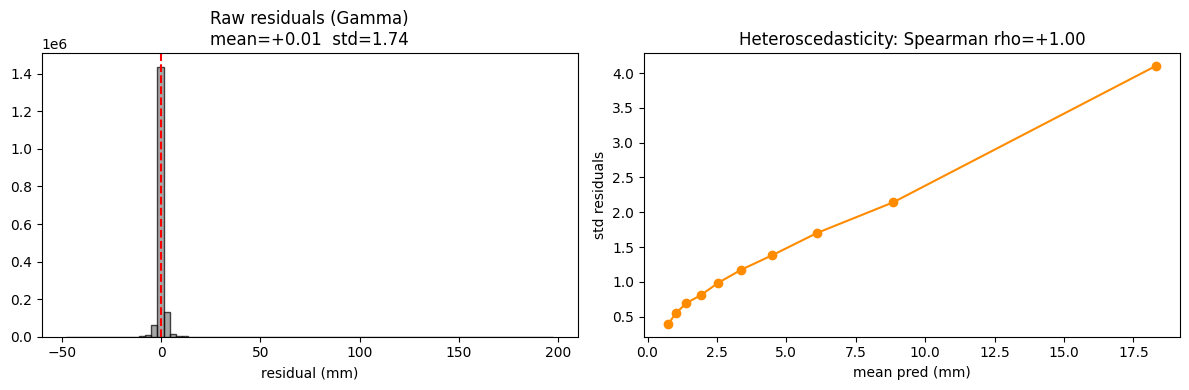

In [9]:
resid_val = y_va.values - y_pred_gamma

deciles = pd.qcut(y_pred_gamma, 10, labels=False, duplicates='drop')
by_decile = pd.DataFrame({'pred': y_pred_gamma, 'resid': resid_val, 'd': deciles}).groupby('d').agg(
    mean_pred=('pred', 'mean'), std_resid=('resid', 'std'), n=('resid', 'size'),
)
rho, p_rho = spearmanr(by_decile['mean_pred'], by_decile['std_resid'])

print(f'mean      = {resid_val.mean():+.3f} mm')
print(f'std       = {resid_val.std():.3f} mm')
print(f'skew      = {skew(resid_val):+.3f}')
print(f'kurtosis  = {kurtosis(resid_val):+.3f}   (excess)')
print(f'Spearman rho = {rho:+.3f}   (p={p_rho:.3g}; <0.4 = homoscedastic)')
print()
print(by_decile.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(resid_val, bins=80, color='gray', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', ls='--')
axes[0].set_xlabel('residual (mm)'); axes[0].set_title(f'Raw residuals (Gamma)\nmean={resid_val.mean():+.2f}  std={resid_val.std():.2f}')
axes[1].plot(by_decile['mean_pred'], by_decile['std_resid'], 'o-', color='darkorange')
axes[1].set_xlabel('mean pred (mm)'); axes[1].set_ylabel('std residuals')
axes[1].set_title(f'Heteroscedasticity: Spearman rho={rho:+.2f}')
plt.tight_layout(); plt.show()

## 9. Quantile regression (11 levels → CRPS)

Train a separate LGB with `objective='quantile'` for each level alpha.
CRPS = 2 * integral_0^1 rho_alpha(y, q_alpha) dalpha — quantile decomposition of the continuous ranked score.
11 quantiles approximate the integral well enough.

Time: ~40–60 s per model x 11 = ~10 min.

In [10]:
QUANTILES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

params_q = dict(
    objective='quantile',
    metric='quantile',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    verbosity=-1,
    random_state=42,
)

q_models = {}
t0 = time.time()
for q in QUANTILES:
    p = {**params_q, 'alpha': q}
    m = LGBMRegressor(**p)
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[early_stopping(30, first_metric_only=True), log_evaluation(500)],
    )
    q_models[q] = m
    print(f'  q={q:.2f}  best_iter={m.best_iteration_}')

print(f'\nquantile models: {time.time()-t0:.1f}s total')

Training until validation scores don't improve for 30 rounds
[500]	valid_0's quantile: 0.113611
Early stopping, best iteration is:
[653]	valid_0's quantile: 0.113588
Evaluated only: quantile
  q=0.05  best_iter=653
Training until validation scores don't improve for 30 rounds
[500]	valid_0's quantile: 0.182968
Early stopping, best iteration is:
[826]	valid_0's quantile: 0.1827
Evaluated only: quantile
  q=0.10  best_iter=826
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[412]	valid_0's quantile: 0.277827
Evaluated only: quantile
  q=0.20  best_iter=412
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[458]	valid_0's quantile: 0.337187
Evaluated only: quantile
  q=0.30  best_iter=458
Training until validation scores don't improve for 30 rounds
[500]	valid_0's quantile: 0.37352
Early stopping, best iteration is:
[882]	valid_0's quantile: 0.372963
Evaluated only: quantile
  q=0.40  best_iter=88

## 10. Kriging preparation

- `train_diag`: train stations with **log-residuals** `log(y/y_hat)` — variance-stabilising for Gamma
- `val_df`: val stations with Gamma prediction and 11 quantiles (sorted by date)

In [11]:
# Re-derive train/val from df — safe on partial re-run
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()
X_tr, y_tr = train[FEATURE_COLS], train['precip_mm']
X_va, y_va = val[FEATURE_COLS],   val['precip_mm']

# Train: log-residuals log(y/y_hat) — variance-stabilising transform for Gamma
# Var(log(y/y_hat)) ~ 1/phi = const  (independent of mu)
y_pred_tr_gamma = np.clip(model_gamma.predict(X_tr), 0.5, None)
train_diag = train[['date', 'station_id', 'x_proj', 'y_proj', 'precip_mm']].copy()
train_diag['gamma_pred'] = y_pred_tr_gamma
train_diag['residual']   = np.log(train_diag['precip_mm'] / train_diag['gamma_pred'])
train_diag['date']       = pd.to_datetime(train_diag['date'])

# Val with all quantile predictions — sort by date to match kriging loop output
val_df = val[['date', 'station_id', 'x_proj', 'y_proj', 'precip_mm']].copy()
val_df['date'] = pd.to_datetime(val_df['date'])
val_df['gamma_pred'] = np.clip(model_gamma.predict(X_va), 0.5, None)

for q in QUANTILES:
    val_df[f'q{q:.2f}'] = np.clip(q_models[q].predict(X_va), 0.0, None)

val_df = val_df.sort_values(['date', 'station_id']).reset_index(drop=True)
Q_COLS = [f'q{q:.2f}' for q in QUANTILES]

# Raw quantile matrix (n_val, 11) — force monotone
q_preds_raw = np.sort(np.clip(val_df[Q_COLS].to_numpy(), 0.0, None), axis=1)

print(f'train_diag rows: {len(train_diag):,}   val_df rows: {len(val_df):,}')
print(f'log-residual: mean={train_diag["residual"].mean():+.3f}  std={train_diag["residual"].std():.3f}')

# Heteroscedasticity of log-residuals
deciles_tr = pd.qcut(train_diag['gamma_pred'], 10, labels=False, duplicates='drop')
by_d = pd.DataFrame({'pred': train_diag['gamma_pred'], 'r': train_diag['residual'], 'd': deciles_tr}).groupby('d').agg(
    mean_pred=('pred', 'mean'), std_r=('r', 'std'),
)
rho_log, _ = spearmanr(by_d['mean_pred'], by_d['std_r'])
print(f'Spearman rho (log-residuals): {rho_log:+.3f}  (was +1.000 for raw)')

train_diag rows: 6,620,310   val_df rows: 1,666,528
log-residual: mean=-0.055  std=0.334
Spearman rho (log-residuals): -0.733  (was +1.000 for raw)


## 11. Pooled variogram on log-residuals (TRAIN)

In [12]:
def pooled_variogram(df, value_col, max_dist_km=500.0, n_lags=20):
    """Pooled empirical semi-variance across all days."""
    edges   = np.linspace(0, max_dist_km * 1000.0, n_lags + 1)
    sum_sqd = np.zeros(n_lags)
    counts  = np.zeros(n_lags, dtype=np.int64)
    for _, sub in df.groupby('date'):
        coords = sub[['x_proj', 'y_proj']].to_numpy()
        vals   = sub[value_col].to_numpy()
        if len(coords) < 2:
            continue
        dists = pdist(coords)
        sqd   = pdist(vals.reshape(-1, 1), metric='sqeuclidean')
        bin_idx = np.searchsorted(edges, dists, side='right') - 1
        valid = (bin_idx >= 0) & (bin_idx < n_lags)
        np.add.at(sum_sqd, bin_idx[valid], sqd[valid])
        np.add.at(counts,  bin_idx[valid], 1)
    gamma = 0.5 * sum_sqd / counts
    centers_km = (edges[:-1] + edges[1:]) / 2 / 1000.0
    return centers_km, gamma, counts

t0 = time.time()
h_emp, g_emp, n_pairs = pooled_variogram(train_diag, 'residual')
print(f'variogram: {time.time()-t0:.1f}s   total pairs: {n_pairs.sum():,}')

variogram: 112.3s   total pairs: 4,634,729,716


exponential: nugget=0.085  psill=0.045  range=500.0 km  sill=0.130


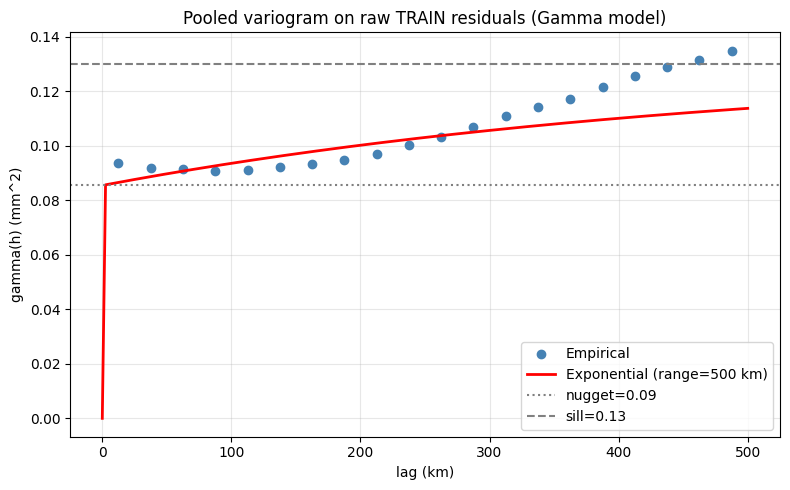

In [13]:
def exponential(h, c0, c, a):
    h = np.asarray(h, dtype=float)
    out = np.zeros_like(h)
    m = h > 0
    out[m] = c0 + c * (1.0 - np.exp(-h[m] / a))
    return out

valid = ~np.isnan(g_emp) & (h_emp <= 350)
p0 = [g_emp[valid][0], g_emp[valid].max() - g_emp[valid][0], 50.0]
popt, _ = curve_fit(
    exponential, h_emp[valid], g_emp[valid], p0=p0, maxfev=5000,
    bounds=([0.0, 0.0, 1.0], [g_emp[valid].max() * 2, g_emp[valid].max() * 5, 500.0]),
)
nugget, partial_sill, range_km = popt
sill = nugget + partial_sill
print(f'exponential: nugget={nugget:.3f}  psill={partial_sill:.3f}  range={range_km:.1f} km  sill={sill:.3f}')

def vgm_fn(h_meters):
    return exponential(np.asarray(h_meters) / 1000.0, nugget, partial_sill, range_km)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(h_emp, g_emp, 'o', color='steelblue', label='Empirical', ms=6)
hh = np.linspace(0, 500, 200)
ax.plot(hh, exponential(hh, nugget, partial_sill, range_km), '-', color='red', lw=2,
        label=f'Exponential (range={range_km:.0f} km)')
ax.axhline(nugget, color='gray', ls=':', label=f'nugget={nugget:.2f}')
ax.axhline(sill, color='gray', ls='--', label=f'sill={sill:.2f}')
ax.set_xlabel('lag (km)'); ax.set_ylabel('gamma(h) (mm^2)')
ax.set_title('Pooled variogram on raw TRAIN residuals (Gamma model)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Local OK — multiplicative correction via log-residuals

Kriging outputs delta_log in log-space.
Back-transform is a simple multiplication:
- point: `y_final = y_lgb * exp(delta_log)`
- quantiles: `q_k_final = q_k * exp(delta_log)`

No MC, no NST^-1.

In [14]:
def ok_local(coords_tr, z_tr, coords_val, vgm_fn, k=50, ridge=1e-6):
    """Vectorised local Ordinary Kriging. Returns (prediction, kriging_variance)."""
    k = min(k, len(coords_tr))
    tree = cKDTree(coords_tr)
    distances, indices = tree.query(coords_val, k=k)
    nbr_coords = coords_tr[indices]
    diff = nbr_coords[:, :, None, :] - nbr_coords[:, None, :, :]
    nbr_h = np.linalg.norm(diff, axis=-1)
    n_val = len(coords_val)
    A = np.ones((n_val, k + 1, k + 1))
    A[:, :k, :k] = vgm_fn(nbr_h) + ridge * np.eye(k)
    A[:, k, k] = 0.0
    b = np.empty((n_val, k + 1))
    b[:, :k] = vgm_fn(distances)
    b[:, k]  = 1.0
    w = np.linalg.solve(A, b[..., None])[..., 0]
    pred   = np.einsum('ij,ij->i', w[:, :k], z_tr[indices])
    sigma2 = np.clip(np.einsum('ij,ij->i', w, b), 0.0, None)
    return pred, sigma2

In [15]:
K_NEIGHBOURS = 50
val_days = sorted(val_df['date'].unique())
print(f'kriging on {len(val_days):,} val days')

train_by_date = dict(tuple(train_diag.groupby('date')))
val_by_date   = dict(tuple(val_df.groupby('date')))

all_true, all_gamma, all_point_corrected, all_delta = [], [], [], []

t0 = time.time()
for d in tqdm(val_days, desc='OK per day'):
    tr_d = train_by_date.get(d)
    vl_d = val_by_date[d]
    if tr_d is None or len(tr_d) < 2:
        delta = np.zeros(len(vl_d))
    else:
        delta, _ = ok_local(
            tr_d[['x_proj', 'y_proj']].to_numpy(),
            tr_d['residual'].to_numpy(),   # log-residuals
            vl_d[['x_proj', 'y_proj']].to_numpy(),
            vgm_fn, k=K_NEIGHBOURS,
        )

    all_true.append(vl_d['precip_mm'].to_numpy())
    all_gamma.append(vl_d['gamma_pred'].to_numpy())
    # back-transform: y_hat * exp(delta_log)
    all_point_corrected.append(vl_d['gamma_pred'].to_numpy() * np.exp(delta))
    all_delta.append(delta)

y_true      = np.concatenate(all_true)
y_gamma     = np.concatenate(all_gamma)
y_corrected = np.concatenate(all_point_corrected)
delta_all   = np.concatenate(all_delta)

print(f'kriging: {time.time()-t0:.1f}s   rows: {len(y_true):,}')
print(f'delta_log: mean={delta_all.mean():+.3f}  std={delta_all.std():.3f}  range=[{delta_all.min():.2f}, {delta_all.max():.2f}]')
print(f'exp(delta): mean={np.exp(delta_all).mean():.3f}  (1.0 = no correction)')

kriging on 7,535 val days


OK per day: 100%|██████████| 7535/7535 [02:21<00:00, 53.15it/s]

kriging: 141.8s   rows: 1,666,528
delta_log: mean=-0.051  std=0.052  range=[-2.02, 1.98]
exp(delta): mean=0.951  (1.0 = no correction)


## 13. Apply exp(delta_log) to quantiles

Multiplicative correction: all quantiles are multiplied by the same factor `exp(delta)`.
This shifts the whole distribution proportionally — small rainfalls get smaller corrections, heavy ones larger.

In [16]:
# Multiplicative correction: q_k * exp(delta_log)
q_corrected = np.sort(
    q_preds_raw * np.exp(delta_all[:, None]),
    axis=1,
)

print(f'q_preds_raw shape: {q_preds_raw.shape}')
print(f'q_corrected shape: {q_corrected.shape}')
print(f'sample row 0:  raw={q_preds_raw[0].round(2)}')
print(f'               cor={q_corrected[0].round(2)}')

q_preds_raw shape: (1666528, 11)
q_corrected shape: (1666528, 11)
sample row 0:  raw=[2.1  2.8  3.42 3.62 3.96 4.37 4.57 4.81 5.35 6.25 6.83]
               cor=[1.95 2.61 3.18 3.37 3.68 4.07 4.26 4.48 4.98 5.82 6.36]


## 14. CRPS + summary table

`mean_crps(samples, obs)` is the energy-score form of CRPS:
```
CRPS = E|X - y| - 0.5 * E|X - X'|
```
where X ~ F_hat (our quantile ensemble). Theoretically equivalent to the integral form.

In [17]:
heavy = y_true >= 20.0

def point_metrics_full(yt, yp, heavy):
    return dict(
        RMSE=float(np.sqrt(mean_squared_error(yt, yp))),
        MAE=float(mean_absolute_error(yt, yp)),
        R2=float(r2_score(yt, yp)),
        MAE_heavy=float(mean_absolute_error(yt[heavy], yp[heavy])),
        bias_heavy=float(np.mean(yp[heavy] - yt[heavy])),
    )

def mean_crps(samples, obs):
    """Energy-score CRPS from ensemble samples."""
    mae = np.abs(samples - obs[:, None]).mean(axis=1)
    s = np.sort(samples, axis=1)
    K = samples.shape[1]
    weights = (2 * np.arange(K) - K + 1) / K**2
    spread = (s * weights).sum(axis=1)
    return float((mae - spread).mean())

# Point metrics
m_gamma    = point_metrics_full(y_true, y_gamma, heavy)
m_corrected = point_metrics_full(y_true, y_corrected, heavy)

# CRPS
crps_gamma_point    = float(mean_absolute_error(y_true, y_gamma))   # delta distribution
crps_corrected_point = float(mean_absolute_error(y_true, y_corrected))
crps_q_raw          = mean_crps(q_preds_raw, y_true)
crps_q_corrected    = mean_crps(q_corrected, y_true)

# Comparison table
results = pd.DataFrame({
    'LGB Tweedie (baseline)':  {'RMSE': 1.713, 'MAE': 0.790, 'R2': 0.920, 'bias_heavy': -2.021, 'CRPS': 0.7895},
    'LGB Tweedie + OK NST':    {'RMSE': 2.993, 'MAE': 2.272, 'R2': 0.757, 'bias_heavy': -0.179, 'CRPS': 0.8340},
    'LGB Gamma (point)':       {**m_gamma,    'CRPS': crps_gamma_point},
    'LGB Gamma + OK':          {**m_corrected, 'CRPS': crps_corrected_point},
    'Quantile (raw)':          {'RMSE': None, 'MAE': None, 'R2': None,
                                'bias_heavy': None, 'CRPS': crps_q_raw},
    'Quantile + OK':           {'RMSE': None, 'MAE': None, 'R2': None,
                                'bias_heavy': None, 'CRPS': crps_q_corrected},
}).T

print(results.round(4).to_string())
print()
print(f'Key: CRPS Quantile raw     = {crps_q_raw:.4f}')
print(f'     CRPS Quantile + OK    = {crps_q_corrected:.4f}')
print(f'     CRPS LGB Gamma point  = {crps_gamma_point:.4f}  (= MAE)')
print(f'     CRPS baseline Tweedie = 0.7895')

                          RMSE     MAE      R2  bias_heavy    CRPS  MAE_heavy
LGB Tweedie (baseline)  1.7130  0.7900  0.9200     -2.0210  0.7895        NaN
LGB Tweedie + OK NST    2.9930  2.2720  0.7570     -0.1790  0.8340        NaN
LGB Gamma (point)       1.7370  0.7906  0.9180     -2.1327  0.7906     4.0096
LGB Gamma + OK          1.7238  0.7838  0.9192     -2.7276  0.7838     4.1899
Quantile (raw)             NaN     NaN     NaN         NaN  0.5966        NaN
Quantile + OK              NaN     NaN     NaN         NaN  0.6009        NaN

Key: CRPS Quantile raw     = 0.5966
     CRPS Quantile + OK    = 0.6009
     CRPS LGB Gamma point  = 0.7906  (= MAE)
     CRPS baseline Tweedie = 0.7895


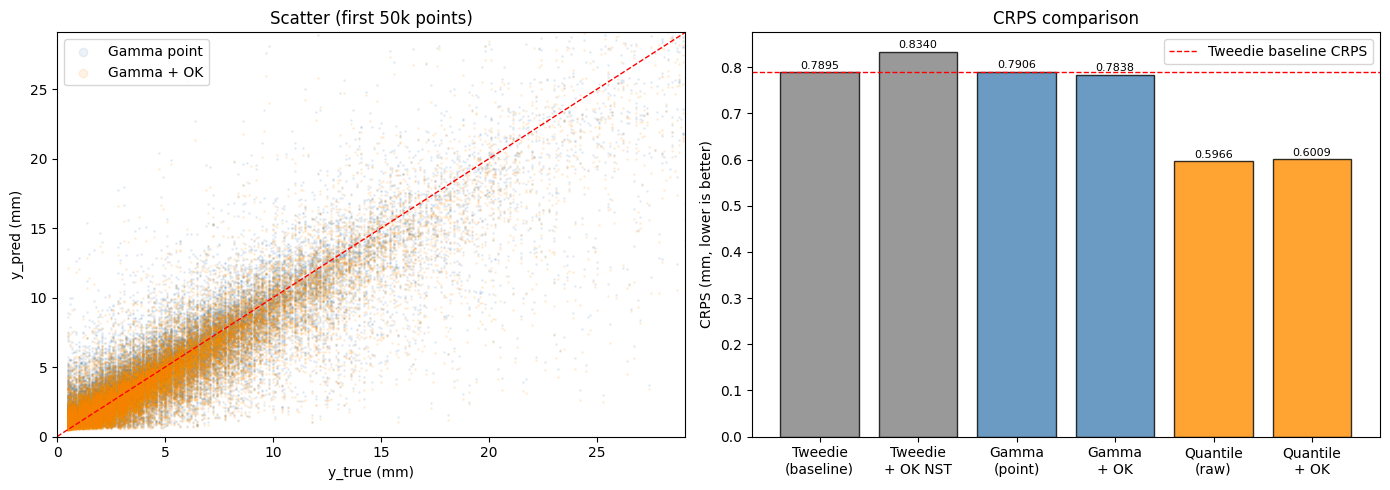

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: gamma vs corrected
lim = min(np.percentile(y_true, 99), 60)
axes[0].scatter(y_true[:50000], y_gamma[:50000], s=1, alpha=0.1, color='steelblue', label='Gamma point')
axes[0].scatter(y_true[:50000], y_corrected[:50000], s=1, alpha=0.1, color='darkorange', label='Gamma + OK')
axes[0].plot([0, lim], [0, lim], 'r--', lw=1)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel('y_true (mm)'); axes[0].set_ylabel('y_pred (mm)')
axes[0].set_title('Scatter (first 50k points)')
axes[0].legend(markerscale=6)

# CRPS bar chart
models_crps = {
    'Tweedie\n(baseline)': 0.7895,
    'Tweedie\n+ OK NST': 0.8340,
    'Gamma\n(point)': crps_gamma_point,
    'Gamma\n+ OK': crps_corrected_point,
    'Quantile\n(raw)': crps_q_raw,
    'Quantile\n+ OK': crps_q_corrected,
}
colors = ['gray', 'gray', 'steelblue', 'steelblue', 'darkorange', 'darkorange']
bars = axes[1].bar(models_crps.keys(), models_crps.values(), color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(0.7895, color='red', ls='--', lw=1, label='Tweedie baseline CRPS')
axes[1].set_ylabel('CRPS (mm, lower is better)')
axes[1].set_title('CRPS comparison')
axes[1].legend()
for bar, val in zip(bars, models_crps.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()